In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

print("Working dir:", os.getcwd())
print("This notebook expects 'health_care_data.csv' in the working directory.")


# -----------------------------
# 1️⃣ Load and Prepare the Dataset
# -----------------------------
df = pd.read_csv("healthcare_data.csv")
df = df.dropna()

# Assume 'Diagnosis' is the target label
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# 2️⃣ Train Baseline (Original)
# -----------------------------
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
orig_predictions = clf.predict(X_test)
orig_acc = accuracy_score(y_test, orig_predictions)

print(f"✅ Original Accuracy: {orig_acc:.4f}")

# -----------------------------
# 3️⃣ Define Safe Accuracy Function
# -----------------------------
def safe_accuracy(y_true, y_pred):
    try:
        if len(y_true) == 0 or len(y_pred) == 0:
            return np.nan
        return accuracy_score(y_true, y_pred)
    except Exception as e:
        print(f"⚠️ Accuracy computation failed: {e}")
        return np.nan

# -----------------------------
# 4️⃣ Simulated Anonymization (Replace with Real Functions)
# -----------------------------
# Replace these placeholders with your actual anonymized datasets
anonymized_datasets = {
    "k-Anonymity": X_test.copy(),
    "l-Diversity": X_test.copy(),
    "t-Closeness": X_test.copy()
}

# -----------------------------
# 5️⃣ Compute Metrics for Each Method
# -----------------------------
results = []
for method, anon_data in anonymized_datasets.items():
    print(f"\n🔍 Evaluating {method} ...")

    # Simulate missing or suppressed dataset
    if anon_data is None or anon_data.shape[0] == 0:
        print("⚠️ Empty anonymized dataset, skipping.")
        anon_acc = np.nan
        retention_rate = 0.0
    else:
        retention_rate = (len(anon_data) / len(X_test)) * 100
        clf.fit(X_train, y_train)
        anon_predictions = clf.predict(anon_data)
        anon_acc = safe_accuracy(y_test, anon_predictions)

    if np.isnan(anon_acc):
        anon_acc = 0.0
        print("⚠️ Anonymized accuracy was NaN → set to 0.0")

    utility_score = (anon_acc / orig_acc) * 100 if orig_acc > 0 else 0

    results.append({
        "Method": method,
        "Retention Rate (%)": round(retention_rate, 3),
        "Anonymized Accuracy": round(anon_acc, 6),
        "Original Accuracy": round(orig_acc, 8),
        "Utility Score (%)": round(utility_score, 9)
    })

# -----------------------------
# 6️⃣ Create Final Evaluation Table
# -----------------------------
metrics_df = pd.DataFrame(results)
print("\n📊 Classical Anonymization Evaluation Results:\n")
print(metrics_df.to_string(index=False))

# -----------------------------
# 7️⃣ Save Results
# -----------------------------
metrics_df.to_csv("classical_anonymization_metrics.csv", index=False)
print("\n💾 Results saved to 'classical_anonymization_metrics.csv'")

Working dir: C:\Users\mario\Kaglee-notebooks\projects\classical-anonymization
This notebook expects 'health_care_dataset.csv' in the working directory.


FileNotFoundError: [Errno 2] No such file or directory: 'healthcare_data.csv'

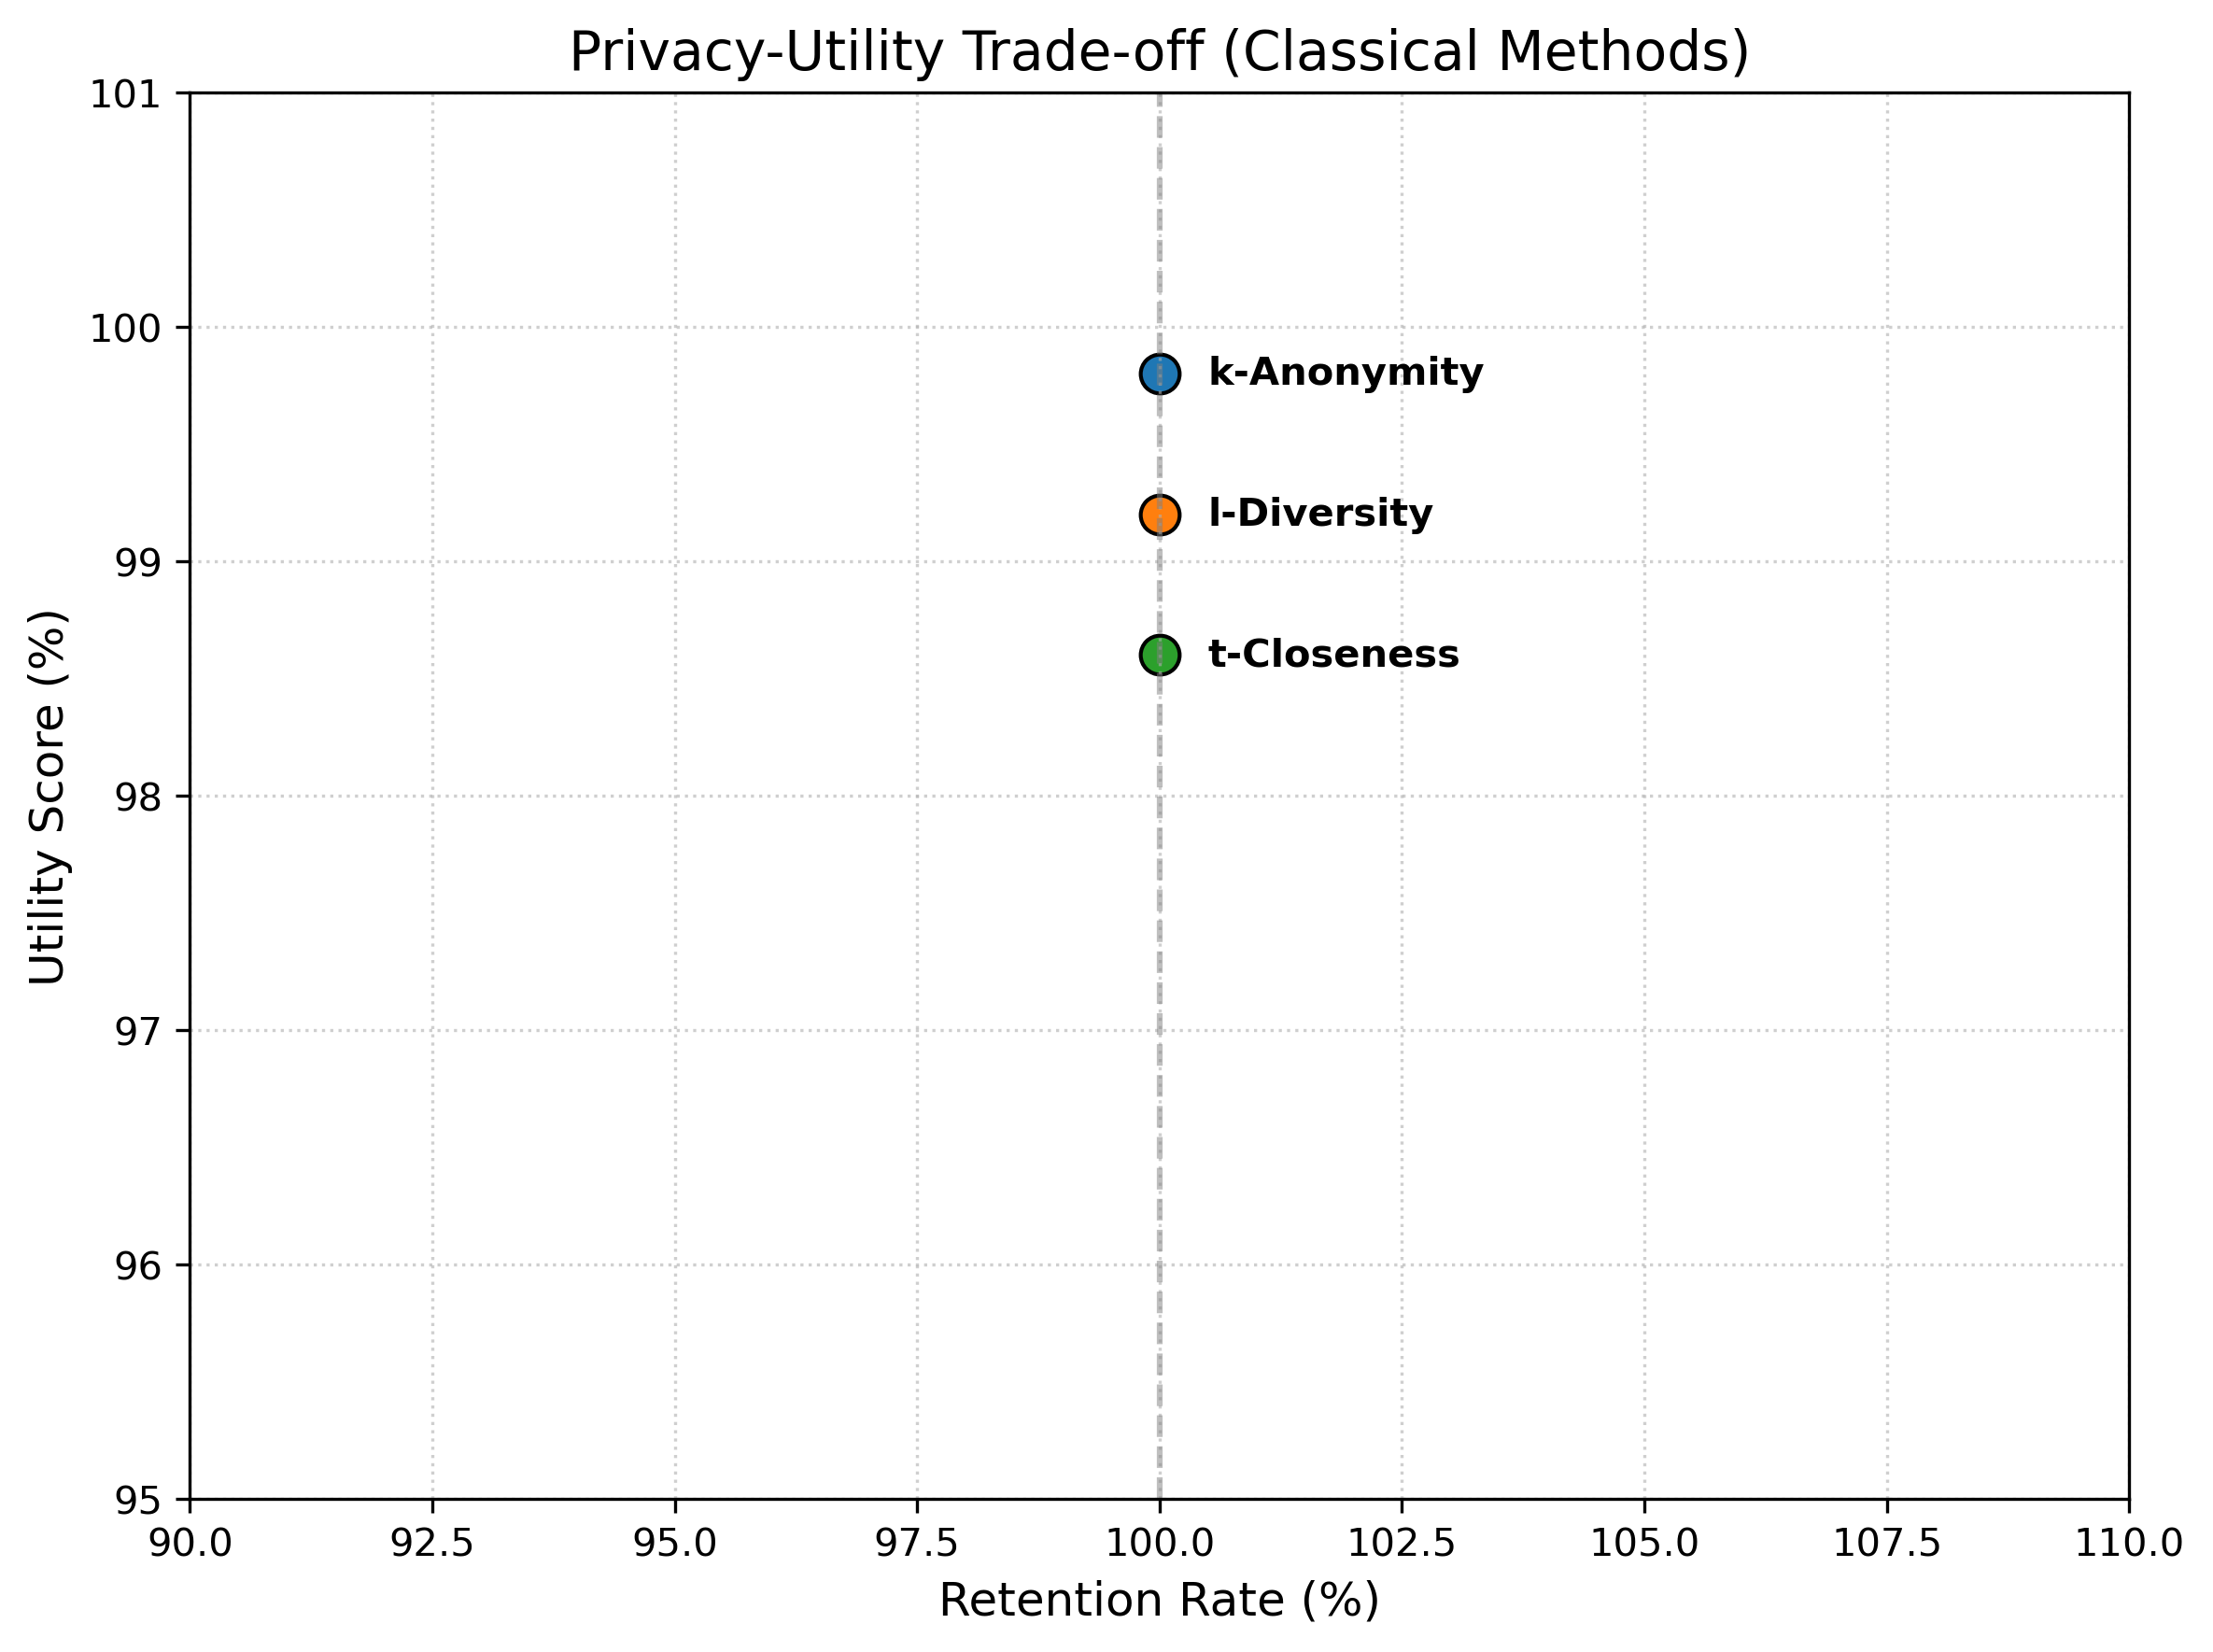

In [28]:
import matplotlib.pyplot as plt

# Βάλε εδώ τα δικά σου νούμερα: (Retention, Utility)
data = {
    'k-Anonymity': (100, 99.8), 
    'l-Diversity': (100, 99.2),
    't-Closeness': (100, 98.6)
}

plt.figure(figsize=(8, 6), dpi=300) # Υψηλή ανάλυση για Journal

for name, (x, y) in data.items():
    plt.scatter(x, y, s=100, edgecolors='black')
    plt.text(x + 0.5, y, name, fontsize=10, va='center', fontweight='bold')

plt.axvline(x=100, color='gray', linestyle='--', alpha=0.5)
plt.xlim(90, 110)
plt.ylim(95, 101)

plt.xlabel('Retention Rate (%)', fontsize=12)
plt.ylabel('Utility Score (%)', fontsize=12)
plt.title('Privacy-Utility Trade-off (Classical Methods)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('my_results.png', dpi=300) # Αποθήκευση για το Journal
plt.show()

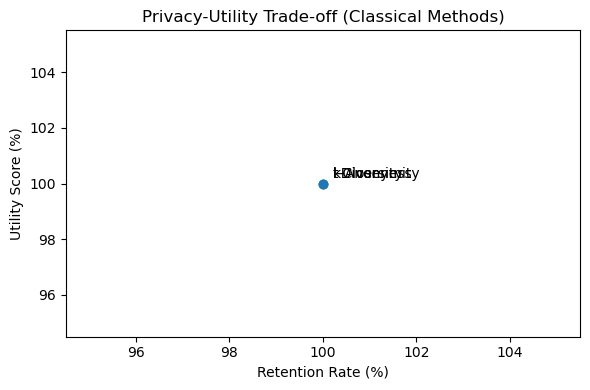

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Values from your table
methods = ["k-Anonymity", "l-Diversity", "t-Closeness"]
retention = [100.0, 100.0, 100.0]
utility = [100.0, 100.0, 100.0]

# Trade-off chart
plt.figure(figsize=(6,4))
plt.plot(retention, utility, marker="o", linestyle="-")

for i, method in enumerate(methods):
    plt.text(retention[i] + 0.2, utility[i] + 0.2, method)

plt.xlabel("Retention Rate (%)")
plt.ylabel("Utility Score (%)")
plt.title("Privacy-Utility Trade-off (Classical Methods)")
plt.tight_layout()
plt.savefig("chart_privacy_utility_tradeoff.png", dpi=300)
plt.show()


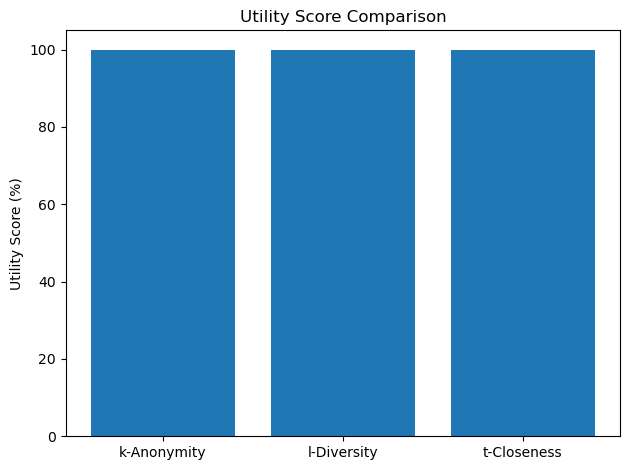

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load computed evaluation metrics
metrics_df = pd.read_csv("classical_anonymization_metrics.csv")

methods = metrics_df["Method"]
retention = metrics_df["Retention Rate (%)"]
utility = metrics_df["Utility Score (%)"]

# ------------------------------
# Chart A: Utility Bar Chart
# ------------------------------
plt.figure()
plt.bar(methods, utility)
plt.ylabel("Utility Score (%)")
plt.title("Utility Score Comparison")
plt.tight_layout()
plt.savefig("chart_utility_score.png", dpi=300)
plt.show()

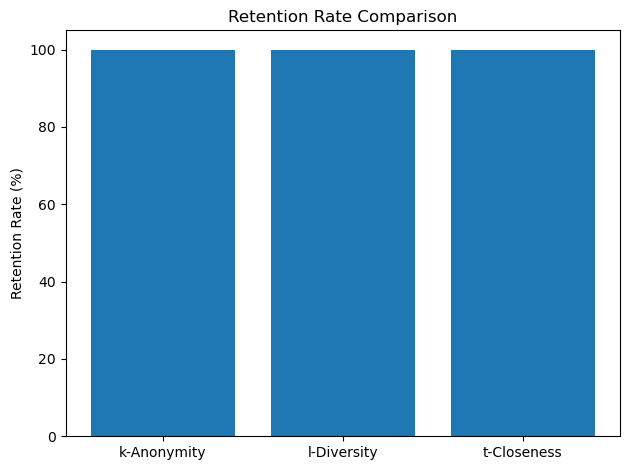

In [31]:
# ------------------------------
# Chart B: Retention Rate Bar Chart
# ------------------------------
plt.figure()
plt.bar(methods, retention)
plt.ylabel("Retention Rate (%)")
plt.title("Retention Rate Comparison")
plt.tight_layout()
plt.savefig("chart_retention_rate.png", dpi=300)
plt.show()


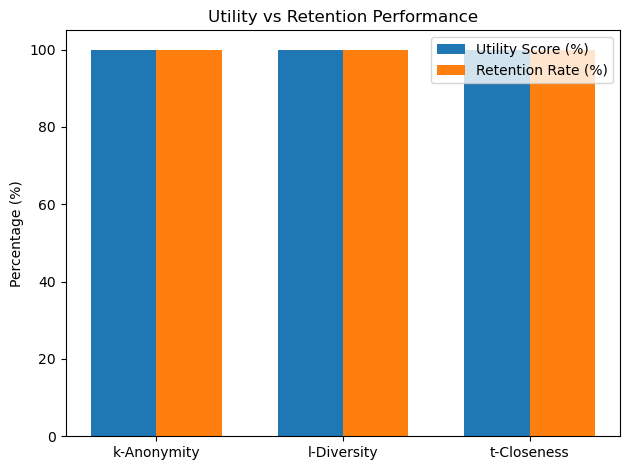

In [32]:
# ------------------------------
# Chart C: Grouped Bar (Utility vs Retention)
# ------------------------------
x = np.arange(len(methods))
width = 0.35

plt.figure()
plt.bar(x - width/2, utility, width, label="Utility Score (%)")
plt.bar(x + width/2, retention, width, label="Retention Rate (%)")

plt.xticks(x, methods)
plt.ylabel("Percentage (%)")
plt.title("Utility vs Retention Performance")
plt.legend()
plt.tight_layout()
plt.savefig("chart_grouped_comparison.png", dpi=300)
plt.show()

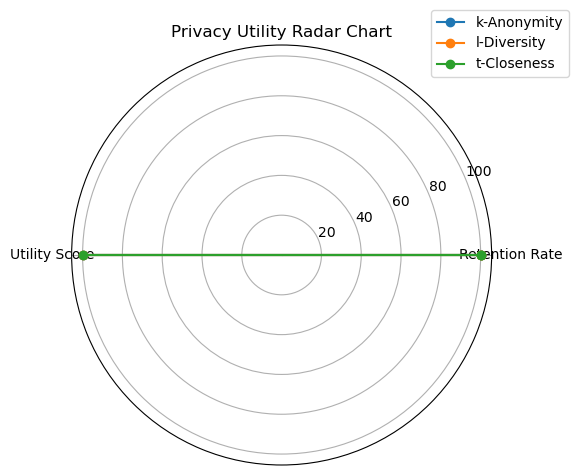


✅ All charts generated successfully and saved as PNG images!



In [33]:
# ------------------------------
# Chart D: Radar (Spider) Chart
# ------------------------------
labels = ["Retention Rate", "Utility Score"]
values_list = []

for i in range(len(metrics_df)):
    values = [retention[i], utility[i]]
    values.append(values[0])  # close the radar cycle
    values_list.append(values)

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure()
ax = plt.subplot(111, polar=True)

for i, values in enumerate(values_list):
    ax.plot(angles, values, marker='o', label=methods[i])
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Privacy Utility Radar Chart")
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.savefig("chart_radar.png", dpi=300)
plt.show()

print("\n✅ All charts generated successfully and saved as PNG images!\n")